#### Assignment 3 - CNN
**Mahshid Bargahi**

This notebook investigates modern deep learning techniques for image classification using the Fashion-MNIST dataset. A custom Convolutional Neural Network (CNN) is developed and evaluated through a series of controlled experiments on architectural hyperparameters, including kernel size, stride, filter count, pooling operations, and network depth.

The effect of data augmentation on generalization is examined, followed by a transfer learning study using a pretrained MobileNetV2 backbone. Model performance is assessed using accuracy, loss, and F1-score, while training dynamics are analyzed through learning curves.

## Import Libraries

In [118]:
import pandas as pd
import numpy as np
import seaborn as sns 
import matplotlib.pyplot as plt 
from keras.models import Sequential
from keras import callbacks
import tensorflow as tf
from sklearn.metrics import f1_score
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout
)
from tensorflow.keras import  Layer

sns.set(color_codes=True)

## Loading the dataset

In [27]:
train_df = pd.read_csv(r"D:\sharif\ADS\assignments\assignment3\CNN\fashion-mnist_train.csv")
test_df = pd.read_csv(r"D:\sharif\ADS\assignments\assignment3\CNN\fashion-mnist_test.csv")

train_df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


## Getting some insight about dataset

In [30]:
train_df["label"]

0        2
1        9
2        6
3        0
4        3
        ..
59995    9
59996    1
59997    8
59998    8
59999    7
Name: label, Length: 60000, dtype: int64

Each example is assigned to one of the following labels:

- 0 T-shirt/top
- 1 Trouser
- 2 Pullover
- 3 Dress
- 4 Coat
- 5 Sandal
- 6 Shirt
- 7 Sneaker
- 8 Bag
- 9 Ankle boot


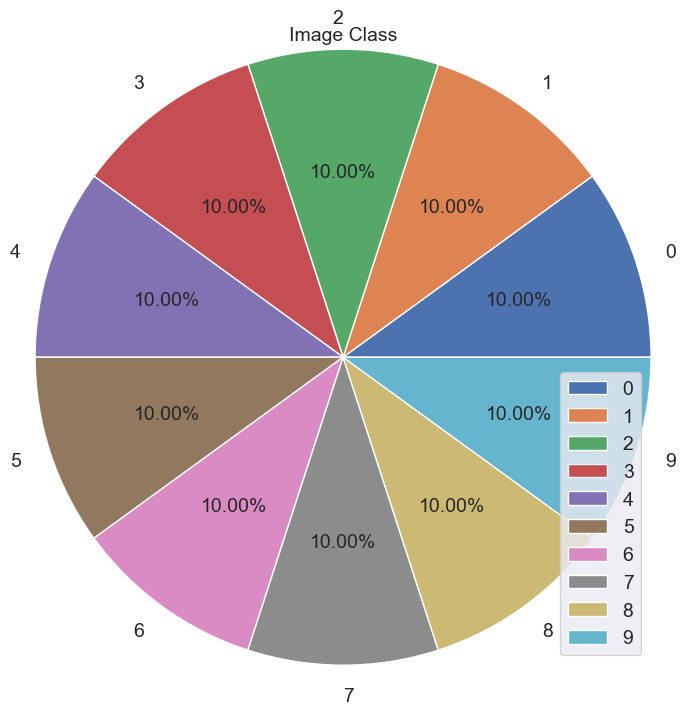

In [38]:
# visualize distribution of classes in train set
selected_labels = range(0,10)
train_df['label'].value_counts().plot(
    kind = 'pie',figsize=(16,8),autopct='%1.2f%%',ylabel='',radius=1.25,labels=selected_labels,fontsize=14)

# Now let's setup the labels, titles and format y axis as percentages
plt.title("Image Class",fontsize=14)
plt.legend(selected_labels,loc='lower right',fontsize=14)
plt.show()


The classes are equaly distributed in the train set (10% each).

Now let's plot few images from the train and test sets.   

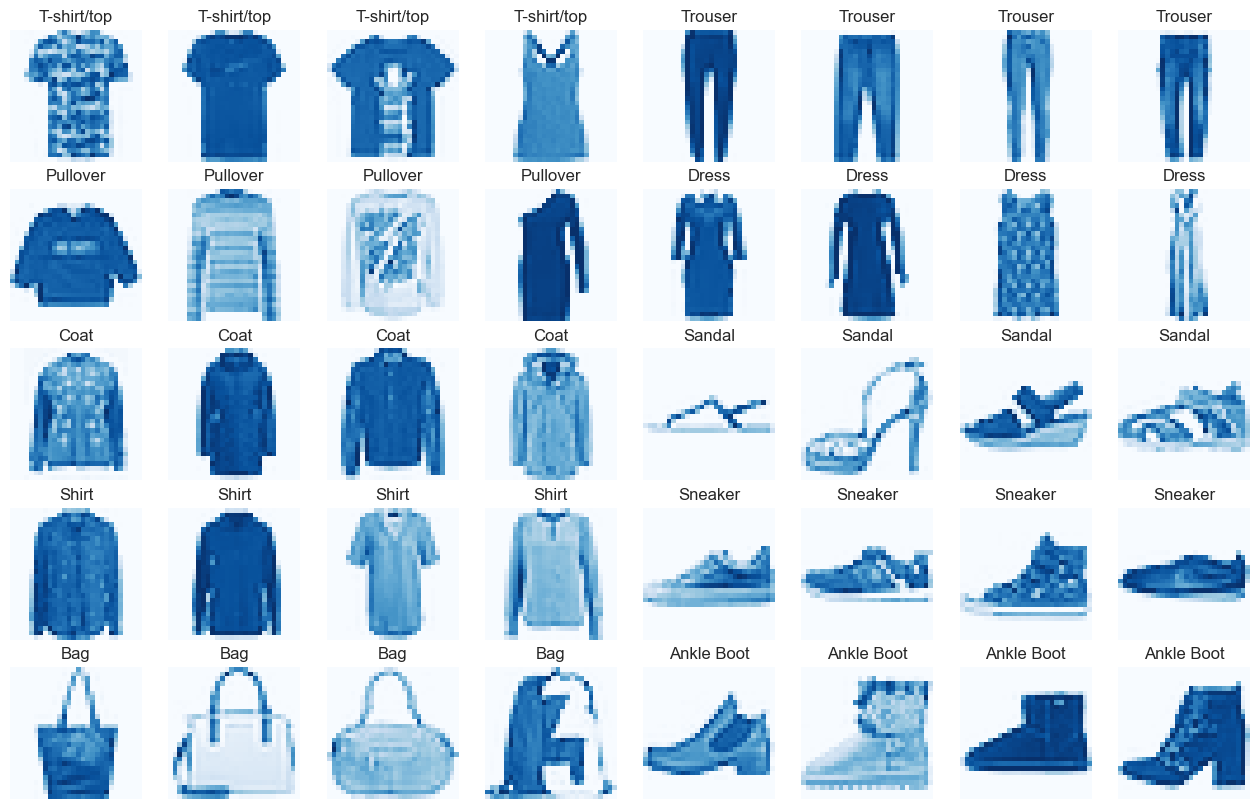

In [37]:
labels = {0 : "T-shirt/top", 1: "Trouser", 2: "Pullover", 3: "Dress", 4: "Coat",
          5: "Sandal", 6: "Shirt", 7: "Sneaker", 8: "Bag", 9: "Ankle Boot"}
sample_images = []
sample_labels = []

for k in labels.keys():
    # Get four samples for each category
    samples = train_df[train_df["label"] == k].head(4)
    for j, s in enumerate(samples.values):
        # First column contain labels, hence index should start from 1
        img = np.array(samples.iloc[j, 1:]).reshape(28,28)
        sample_images.append(img)
        sample_labels.append(samples.iloc[j, 0])

f, ax = plt.subplots(5,8, figsize=(16,10))

for i, img in enumerate(sample_images):
    ax[i//8, i%8].imshow(img, cmap="Blues")
    ax[i//8, i%8].axis('off')
    ax[i//8, i%8].set_title(labels[sample_labels[i]])
plt.show()    

## Train / Test Split

In [39]:
X_train = train_df.drop("label", axis=1).values
y_train = train_df["label"].values

X_test = test_df.drop("label", axis=1).values
y_test = test_df["label"].values

print(X_train.shape)
print(X_test.shape)

(60000, 784)
(10000, 784)


## Normalization/Stadardization

Pixel values in Fashion-MNIST range from 0 to 255.
 
Dividing by 255 scales all pixel intensities to the range [0,1]. 

This normalization improves numerical stability, helps gradient-based optimization converge faster, and generally leads to better training performance.

In [40]:
X_train = X_train/255.
X_test = X_test/255.

We reshape the columns  from (784) to (28,28,1) because a CNN needs the spatial structure of the image.

In [41]:
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

print(X_train.shape)
print(X_test.shape)

(60000, 28, 28, 1)
(10000, 28, 28, 1)


## Encoding the label

The class labels were transformed using one-hot encoding, where each class is represented by a binary vector of length 10. 

Since one-hot encoded labels were used, the model was trained with the categorical cross-entropy loss function together with a softmax output layer.

In [42]:
from tensorflow.keras.utils import to_categorical

y_train = to_categorical(y_train, num_classes=10)
y_test = to_categorical(y_test, num_classes=10)

y_train[0]

array([0., 0., 1., 0., 0., 0., 0., 0., 0., 0.])

# Building CNN With Keras

The baseline CNN contains two convolutional layers followed by max-pooling operations. These layers learn hierarchical visual features from the input images.

The extracted features are then flattened and passed through fully connected layers to perform classification into one of the ten Fashion-MNIST categories.

The final layer uses the Softmax activation function to output class probabilities.


In [86]:
base_model = Sequential()

base_model.add(Conv2D(filters = 8, kernel_size = (5,5),padding = 'Same', 
                 activation ='relu', input_shape = (28,28,1)))
base_model.add(MaxPooling2D(pool_size=(2,2)))

base_model.add(Conv2D(filters=64, kernel_size=(3,3), activation='relu'))
base_model.add(MaxPooling2D(pool_size=(2,2)))

# fully connected
base_model.add(Flatten())
base_model.add(Dense(256, activation = "relu"))
base_model.add(Dropout(0.3))
base_model.add(Dense(10, activation = "softmax"))

base_model.summary()

c:\Users\kavoshrayan\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_24 (Conv2D)              │ (None, 28, 28, 8)      │           208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_23 (MaxPooling2D) │ (None, 14, 14, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_25 (Conv2D)              │ (None, 12, 12, 64)     │         4,672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_24 (MaxPooling2D) │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_11 (Flatten)            │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 256)            │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 597,530 (2.28 MB)

 Trainable params: 597,530 (2.28 MB)

 Non-trainable params: 0 (0.00 B)

The model is trained using the Adam optimizer and categorical cross-entropy loss function. 

In [87]:
base_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

We employ an early Stopping to prevent overfitting and reduce unnecessary training.

The training process monitored validation loss and terminated when no improvement was observed for 5 consecutive epochs.

The best-performing model weights were restored automatically.

In [88]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

A validation set is created from the training data to monitor performance during training and identify potential overfitting.

In [89]:
history = base_model.fit(
    X_train,
    y_train,
    epochs=15,
    batch_size=16,
    validation_split=0.2,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/15
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 49s 15ms/step - accuracy: 0.8336 - loss: 0.4570 - val_accuracy: 0.8797 - val_loss: 0.3253
Epoch 2/15
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 54s 18ms/step - accuracy: 0.8878 - loss: 0.3053 - val_accuracy: 0.9013 - val_loss: 0.2806
Epoch 3/15
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 50s 17ms/step - accuracy: 0.9025 - loss: 0.2626 - val_accuracy: 0.8970 - val_loss: 0.2718
Epoch 4/15
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 50s 17ms/step - accuracy: 0.9122 - loss: 0.2334 - val_accuracy: 0.9021 - val_loss: 0.2614
Epoch 5/15
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 50s 17ms/step - accuracy: 0.9213 - loss: 0.2089 - val_accuracy: 0.9133 - val_loss: 0.2484
Epoch 6/15
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 48s 16ms/step - accuracy: 0.9291 - loss: 0.1898 - val_accuracy: 0.9147 - val_loss: 0.2395
Epoch 7/15
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 47s 16ms/step - accuracy: 0.9358 - loss: 0.1713 - val_accuracy: 0.9131 - val_loss: 0.2586
Epoch 8/15
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 50s 17ms/step - accuracy: 0.9424 -

Now let's plot training curves and performance metrics of model that we trained.

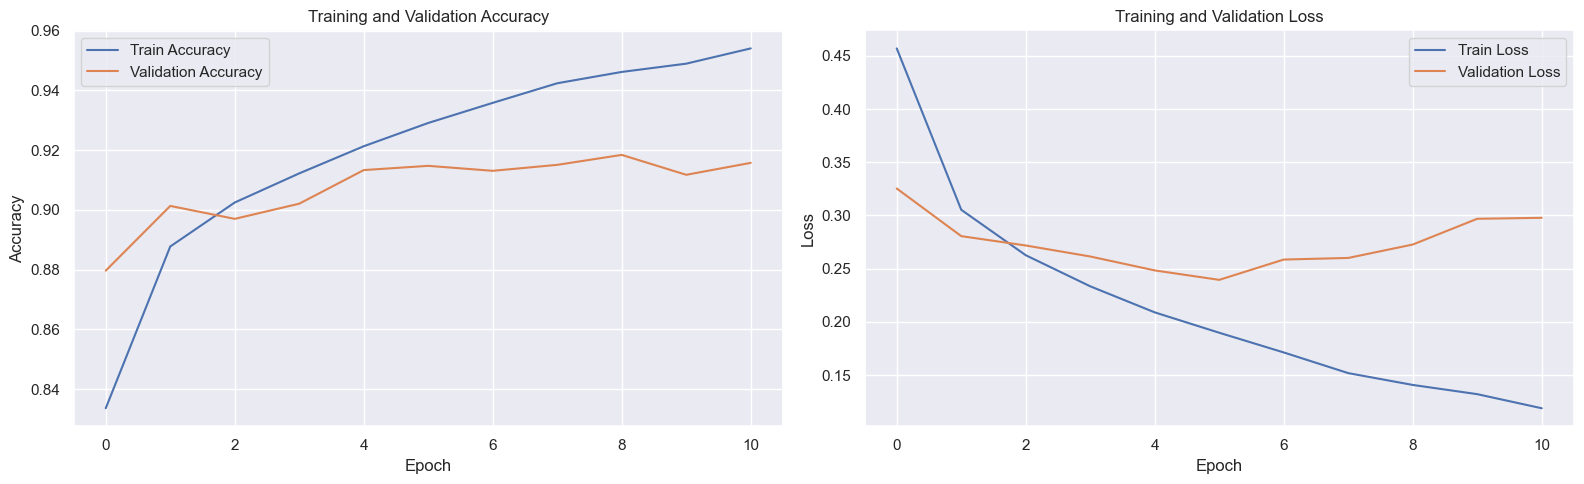

In [90]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Accuracy
axes[0].plot(history.history['accuracy'], label='Train Accuracy')
axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy')
axes[0].set_title('Training and Validation Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

# Loss
axes[1].plot(history.history['loss'], label='Train Loss')
axes[1].plot(history.history['val_loss'], label='Validation Loss')
axes[1].set_title('Training and Validation Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()

In [92]:
# Evaluate model in test set
test_loss, test_accuracy = base_model.evaluate(
    X_test,
    y_test,
    verbose=0
)

y_pred = np.argmax(base_model.predict(X_test, verbose=0), axis=1)
y_true = np.argmax(y_test, axis=1)
f1 = f1_score(y_true, y_pred, average='macro')

print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_accuracy:.4f}")
print(f"F1 Score  : {f1:.4f}")

Test Loss     : 0.2250
Test Accuracy : 0.9209
F1 Score  : 0.9204


Let's visualizing feature maps

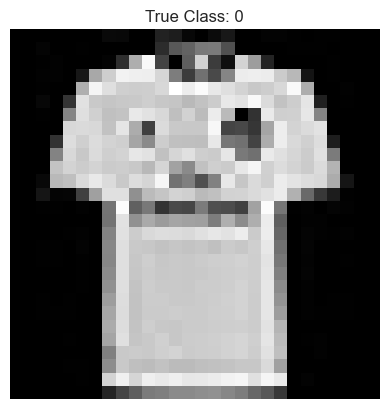

In [110]:
from tensorflow.keras.models import Model

# select an image
image = X_test[0]

plt.imshow(image.squeeze(), cmap='gray')
plt.title(f"True Class: {np.argmax(y_test[0])}")
plt.axis('off')
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step


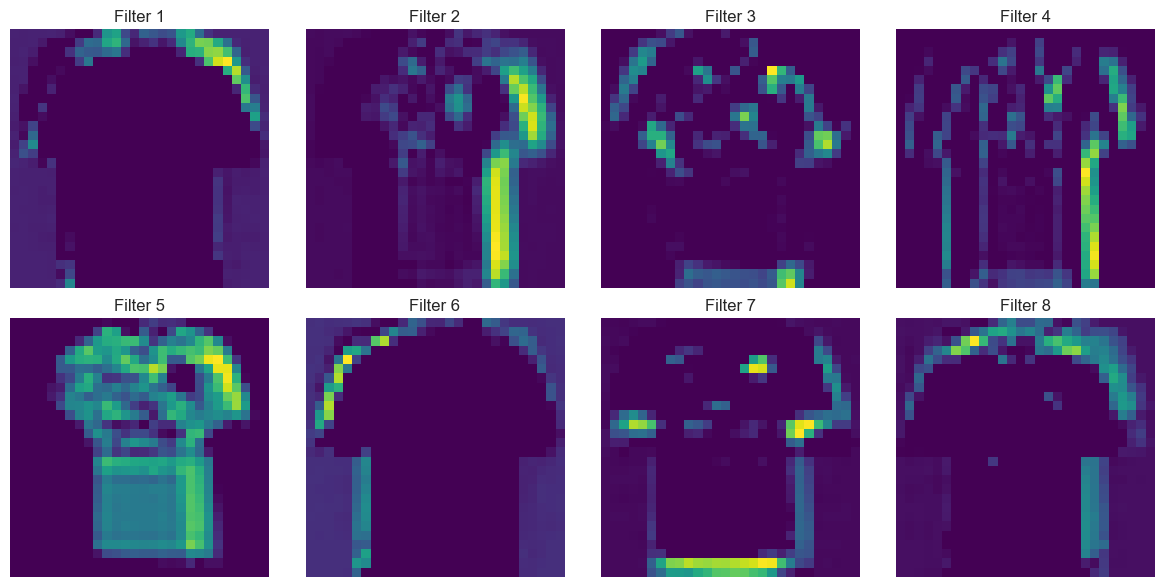

(1, 28, 28, 8)


In [113]:
layer_outputs = [
    layer.output
    for layer in base_model.layers
    if 'conv' in layer.name.lower()
]

activation_model = tf.keras.Model(
    inputs=base_model.inputs,
    outputs=layer_outputs
)

image_batch = np.expand_dims(image, axis=0)
feature_maps = activation_model.predict(image_batch)

# visualize the first convolutional layer
feature_map = feature_maps[0]


# plot feature maps
num_filters = feature_map.shape[-1]

plt.figure(figsize=(12,6))

for i in range(num_filters):

    plt.subplot(2, 4, i + 1)

    plt.imshow(
        feature_map[0, :, :, i],
        cmap='viridis'
    )

    plt.axis('off')
    plt.title(f'Filter {i+1}')

plt.tight_layout()
plt.show()

print(feature_map.shape)

The base model achieved a test accuracy of 92.09% and a test loss of 0.225 on the Fashion-MNIST test set.

The training and validation accuracy curves show that the model successfully learned meaningful visual features from the images.

While training accuracy continued to improve throughout the training process, validation accuracy plateaued around 91–92%. Similarly, validation loss decreased during the early epochs but began to increase after approximately epoch 5, whereas training loss continued to decrease. This behavior indicates mild overfitting.

### Now let's use Key CNN Components and Explain Their Effect


First we define  functions to build model and do experiment for each component analyzing.

In [ ]:
def build_model(
    kernel_size=3,
    stride=1,
    filters=(32, 64),
    pooling='max',
    pool_size=2,
    depth=2
):
    
    model = tf.keras.Sequential()
    
    # first conv block
    model.add(
        tf.keras.layers.Conv2D(
            filters[0],
            kernel_size,
            strides=stride,
            activation='relu',
            input_shape=(28,28,1)
        )
    )

    if pooling == 'max':
        model.add(tf.keras.layers.MaxPooling2D(pool_size=pool_size))
    else:
        model.add(tf.keras.layers.AveragePooling2D(pool_size=pool_size))

    # Additional Conv Blocks
    for i in range(1, depth):
        
        model.add(
            tf.keras.layers.Conv2D(
                filters[min(i, len(filters)-1)],
                kernel_size,
                activation='relu',
                padding='same',
            )
        )

        if pooling == 'max':
            model.add(tf.keras.layers.MaxPooling2D(pool_size=pool_size))
        else:
            model.add(tf.keras.layers.AveragePooling2D(pool_size=pool_size))

    # fully-connected layers
    model.add(tf.keras.layers.Flatten())
    model.add(tf.keras.layers.Dense(128, activation='relu'))
    model.add(tf.keras.layers.Dropout(0.3))
    model.add(tf.keras.layers.Dense(10, activation='softmax'))

    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [97]:
import time

def run_experiment(name, results, **model_kwargs):

    model = build_model(**model_kwargs)

    start = time.time()

    history = model.fit(
        X_train,
        y_train,
        validation_split=0.2,
        epochs=10,
        batch_size=16,
        verbose=0
    )

    training_time = time.time() - start

    test_loss, test_acc = model.evaluate(
        X_test,
        y_test,
        verbose=0
    )

    y_pred = np.argmax(
        model.predict(X_test, verbose=0),
        axis=1
    )

    y_true = np.argmax(y_test, axis=1)


    f1 = f1_score(
        y_true,
        y_pred,
        average='macro'
    )

    results[name] = {
    "Parameters": model.count_params(),
    "Training Time (s)": round(training_time, 2),
    "Test Accuracy": round(test_acc, 4),
    "Test Loss": round(test_loss, 4),
    "F1 Score": round(f1, 4)
}

    return results, history

And finction to plot train vs. validattion loss for each component.

In [ ]:
def plot_all_losses(histories):

    n = len(histories)

    fig, axes = plt.subplots(1, n, figsize=(5*n, 5))

    if n == 1:
        axes = [axes]

    for i, (name, history) in enumerate(histories.items()):

        axes[i].plot(
            history.history['loss'],
            label='Train Loss'
        )

        axes[i].plot(
            history.history['val_loss'],
            label='Validation Loss'
        )

        axes[i].set_title(name)
        axes[i].set_xlabel('Epoch')
        axes[i].set_ylabel('Loss')
        axes[i].legend()
        axes[i].grid(True)

    fig.suptitle('Loss Curves Across Experiments')
    plt.tight_layout()
    plt.show()

In [68]:
def plot_all_val_losses(histories):

    plt.figure(figsize=(8,5))

    for name, history in histories.items():

        plt.plot(
            history.history['val_loss'],
            label=name
        )

    plt.xlabel('Epoch')
    plt.ylabel('Validation Loss')
    plt.title('Validation Loss Comparison')
    plt.legend()
    plt.grid(True)
    plt.show()

#### Kernel sizes (receptive field)

Kernel size determines the receptive field of convolutional filters. Smaller kernels focus on local image patterns, while larger kernels capture information from wider spatial regions.

In [81]:
results = {}
histories = {}

results, histories["Kernel 3x3"] = run_experiment("Kernel 3x3", results, kernel_size=3)

results, histories["Kernel 5x5"] = run_experiment("Kernel 5x5", results, kernel_size=5)

results, histories["Kernel 7x7"] = run_experiment("Kernel 7x7", results, kernel_size=7)

c:\Users\kavoshrayan\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
c:\Users\kavoshrayan\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
c:\Users\kavoshrayan\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().

In [82]:
pd.DataFrame(results).T

,Parameters,Training Time (s),Test Accuracy,Test Loss,F1 Score
Kernel 3x3,315146.0,468.20,0.9135,0.2324,0.9125
Kernel 5x5,348426.0,322.16,0.8880,0.3066,0.8865
Kernel 7x7,308234.0,393.32,0.8709,0.3496,0.8681


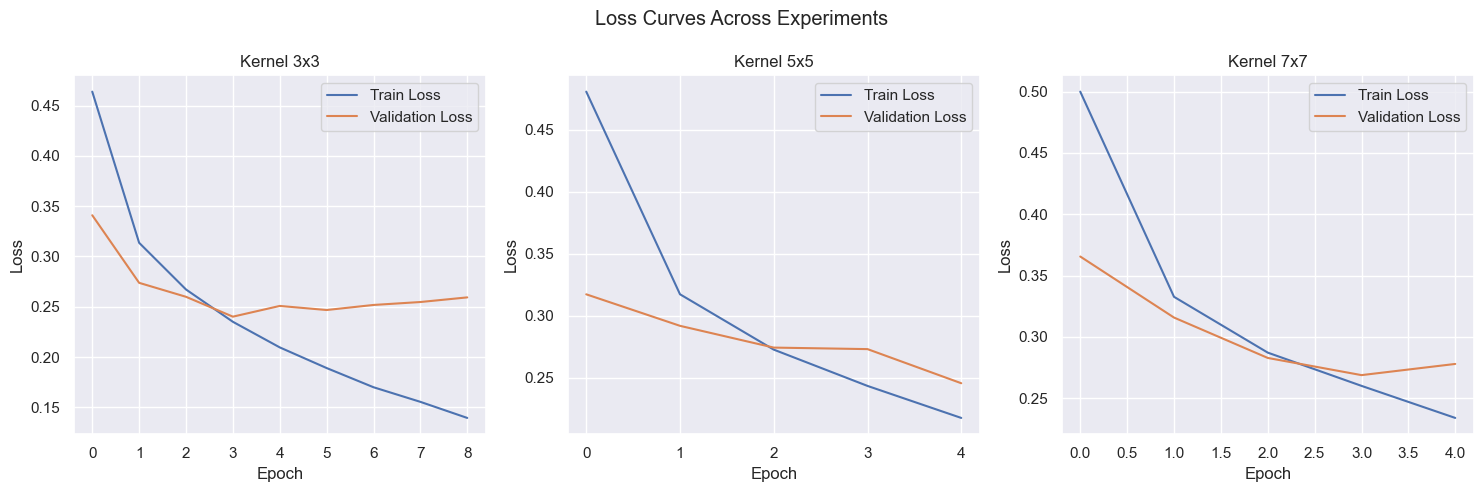

In [83]:

plot_all_losses(histories)

Among the tested configurations,:

- The 3×3 kernel achieved the highest test accuracy (91.35%) and F1-score (91.25%).
-The 5×5 and 7×7 kernels produced lower performance, suggesting that larger receptive fields were less suitable for the small 28×28 Fashion-MNIST images.
- The 3×3 model exhibited a higher degree of overfitting, as training loss continued to decrease while validation loss began to increase after several epochs.
- Larger kernels showed less overfitting but also reduced classification performance.
- Training times varied because different kernel sizes changed the dimensions of intermediate feature maps and interacted with early stopping. Therefore, training time was influenced not only by kernel size but also by the number of completed epochs.

#### Strides

The stride controls how far the convolutional kernel moves across the input image at each step.

To investigate this effect, the base model with stride 1 is compared against a model using stride 2 while keeping all other architectural settings unchanged.

In [93]:
results = {}
histories = {}

results, histories["Stride 1"] = run_experiment(
    "Stride 1",
    results,
    stride=1
)

results, histories["Stride 2"] = run_experiment(
    "Stride 2",
    results,
    stride=2
)

c:\Users\kavoshrayan\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
c:\Users\kavoshrayan\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


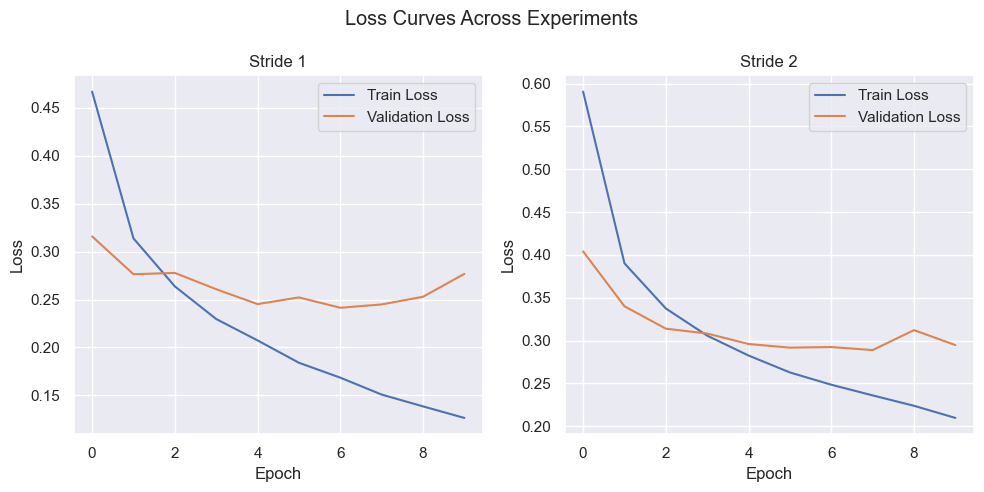

In [94]:
plot_all_losses(histories)

In [95]:
pd.DataFrame(results).T

,Parameters,Training Time (s),Test Accuracy,Test Loss,F1 Score
Stride 1,315146.0,288.58,0.9204,0.2475,0.9201
Stride 2,93962.0,173.65,0.9035,0.2786,0.9028


- Increasing the stride from 1 to 2 reduced the number of model parameters from 315,146 to 93,962 and significantly decreased training time.

- The stride-2 model showed less overfitting, as the gap between training and validation loss was smaller. However, the reduction in spatial resolution also led to lower classification performance.

- Test accuracy decreased from 92.04% to 90.35%, and the F1-score decreased from 0.9201 to 0.9028.

- Overall, larger strides improve computational efficiency but may reduce the model's ability to capture fine-grained image features.

#### Numbers of filters

The number of filters determines how many feature maps are learned by each convolutional layer.

To analyze this effect, models with different numbers of filters are trained while keeping all other architectural and training settings unchanged.

In [98]:
results = {}
histories = {}

results, histories["16-32 Filters"] = run_experiment(
    "16-32 Filters",
    results,
    filters=(16,32)
)

results, histories["32-64 Filters"] = run_experiment(
    "32-64 Filters",
    results,
    filters=(32,64)
)

results, histories["64-128 Filters"] = run_experiment(
    "64-128 Filters",
    results,
    filters=(64,128)
)

c:\Users\kavoshrayan\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
c:\Users\kavoshrayan\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
c:\Users\kavoshrayan\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().

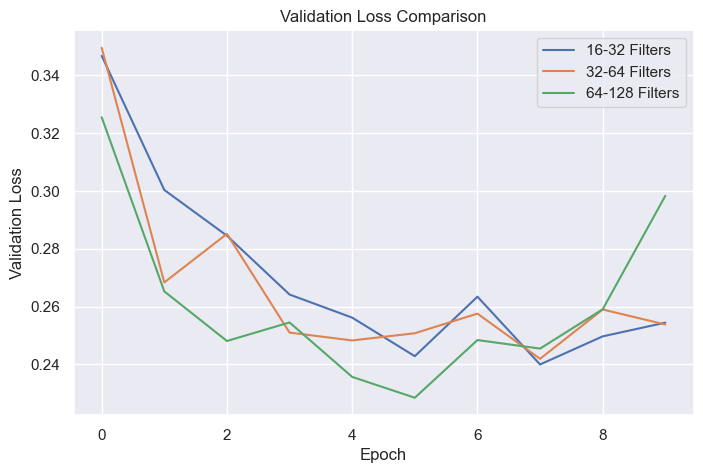

In [99]:
plot_all_val_losses(histories)

In [100]:
pd.DataFrame(results).T

,Parameters,Training Time (s),Test Accuracy,Test Loss,F1 Score
16-32 Filters,153674.0,297.16,0.9171,0.2392,0.9168
32-64 Filters,315146.0,383.00,0.9244,0.2266,0.9244
64-128 Filters,665738.0,707.74,0.9218,0.2775,0.9208


- Increasing the number of filters increases model capacity by allowing the network to capture a wider variety of visual patterns.
- As the number of filters increased from 16-32 to 32-64, test accuracy improved from 91.71% to 92.44%, indicating that additional feature maps helped the model learn more discriminative representations.
- Increasing the filters further to 64-128 substantially increased the number of parameters and training time while providing no performance improvement.
- The validation loss curves suggest that the 64-128 model began to overfit, as validation loss increased during later epochs despite the larger model capacity.
- Overall, the 32-64 configuration provided the best trade-off between accuracy, generalization, and computational cost.

#### Pooling types 

Pooling layers reduce the spatial dimensions of feature maps while retaining important information. 

We compare max pooling and average pooling to evaluate how different pooling strategies affect feature extraction and classification performance.

In [101]:
results = {}
histories = {}

results, histories["Max Pooling"] = run_experiment(
    "Max Pooling",
    results,
    pooling='max'
)

results, histories["Average Pooling"] = run_experiment(
    "Average Pooling",
    results,
    pooling='avg'
)

c:\Users\kavoshrayan\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
c:\Users\kavoshrayan\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


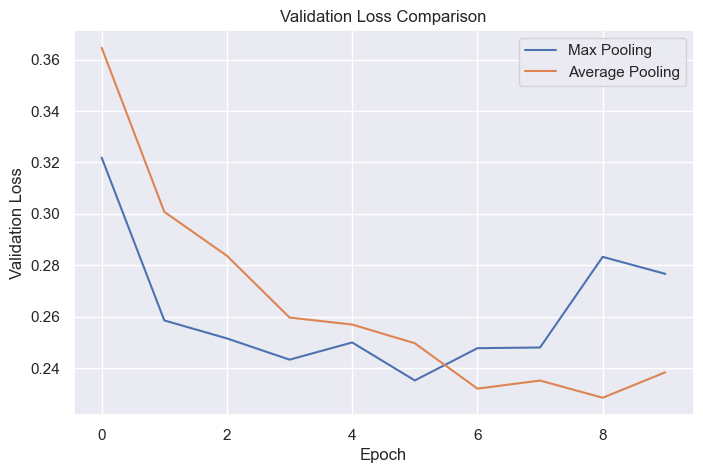

In [ ]:
plot_all_val_losses(histories)

In [103]:
pd.DataFrame(results).T

,Parameters,Training Time (s),Test Accuracy,Test Loss,F1 Score
Max Pooling,315146.0,512.14,0.9244,0.2490,0.9249
Average Pooling,315146.0,609.68,0.9181,0.2251,0.9186


- Both configurations contained the same number of trainable parameters because the pooling operation does not introduce additional weights. - - Max Pooling achieved the highest test accuracy (92.44%) and F1-score (92.49%), indicating that preserving the strongest activations helps capture discriminative image features.
- Average Pooling produced a lower test loss and smoother validation-loss curve, suggesting slightly better regularization and reduced overfitting. However, this came at the cost of lower classification accuracy.
- Overall, Max Pooling provided the best performance for Fashion-MNIST, while Average Pooling offered a modest reduction in overfitting.

#### Pooling window sizes 

The pooling window size determines the degree of spatial downsampling applied to feature maps. 

We compare different pooling sizes while keeping the rest of the architecture unchanged.

In [105]:
results = {}
histories = {}

results, histories["Pool 2x2"] = run_experiment(
    "Pool 2x2",
    results,
    pool_size=2
)

results, histories["Pool 3x3"] = run_experiment(
    "Pool 3x3",
    results,
    pool_size=3
)

c:\Users\kavoshrayan\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


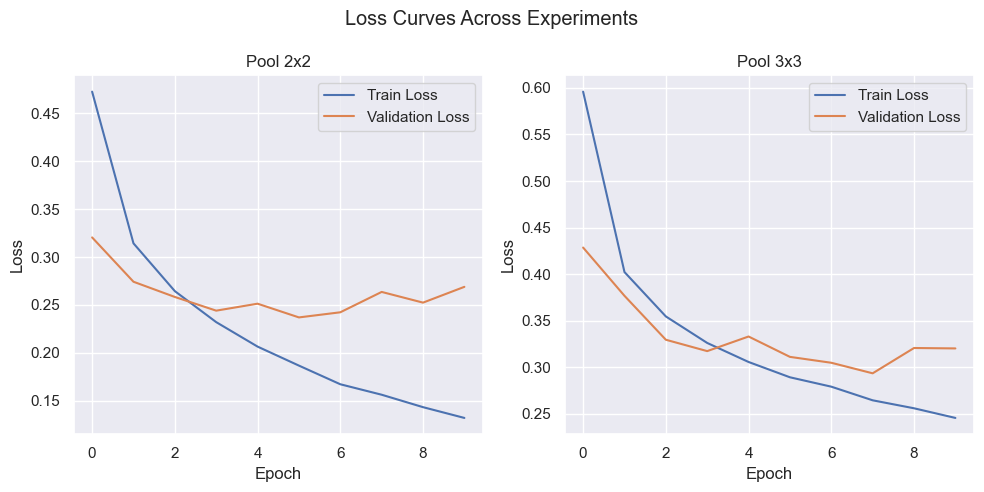

In [106]:
plot_all_losses(histories)

In [107]:
pd.DataFrame(results).T

,Parameters,Training Time (s),Test Accuracy,Test Loss,F1 Score
Pool 2x2,315146.0,343.40,0.9197,0.2523,0.9197
Pool 3x3,53002.0,347.04,0.8927,0.2953,0.8908


- Increasing the pooling size from 2×2 to 3×3 significantly reduced the number of trainable parameters from 315,146 to 53,002 because the resulting feature maps became much smaller before the fully connected layers.
- Although the larger pooling window reduced model complexity and showed less evidence of overfitting, it also removed important spatial details. As a result, test accuracy decreased from 91.97% to 89.27%, and the F1-score decreased from 0.9197 to 0.8908.
- Overall, the 2×2 pooling window provided a better balance between feature preservation and dimensionality reduction, making it more suitable for Fashion-MNIST classification(images have details because of theire types and classes are often distinguished by small details).

#### Depth of the network

Network depth determines the number of convolutional layers used for feature extraction. 

To investigate this effect, shallow, medium, and deep CNN architectures are compared while keeping all other training settings unchanged.

In [114]:
results = {}
histories = {}

results, histories["Depth 1"] = run_experiment(
    "Depth 1",
    results,
    depth=1,
    filters=(32,)
)

results, histories["Depth 2"] = run_experiment(
    "Depth 2",
    results,
    depth=2,
    filters=(32,64)
)

results, histories["Depth 3"] = run_experiment(
    "Depth 3",
    results,
    depth=3,
    filters=(32,64,128)
)

c:\Users\kavoshrayan\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
c:\Users\kavoshrayan\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
c:\Users\kavoshrayan\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().

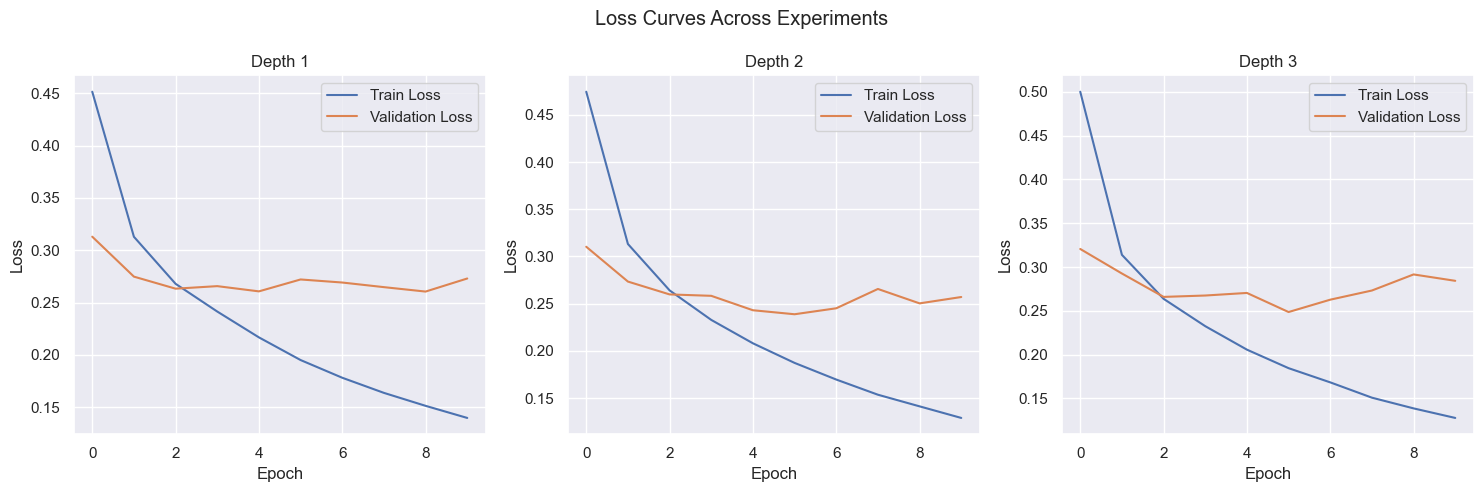

In [115]:
plot_all_losses(histories)

In [116]:
pd.DataFrame(results).T

,Parameters,Training Time (s),Test Accuracy,Test Loss,F1 Score
Depth 1,693962.0,571.93,0.9217,0.2610,0.9211
Depth 2,315146.0,379.09,0.9229,0.2352,0.9233
Depth 3,241546.0,499.79,0.9233,0.2519,0.9230


- Increasing depth allows the model to learn more hierarchical feature representations, ranging from simple edges in early layers to more complex clothing patterns in deeper layers.
- The two-layer and three-layer networks achieved slightly better performance than the single-layer model.
- The depth-2 configuration produced the lowest test loss (0.2352) and highest F1-score (0.9233), indicating the best balance between feature extraction and generalization.
- For depth 1, the feature map before Flatten is much larger, then created hundreds of thousands of Dense-layer weights.
- Adding CNV layers decrease parameters because each additional Conv+Pool block shrinks the feature maps before Flatten
- Deeper networks can learn more abstract representations, the depth-3 model showed signs of increased overfitting, as validation loss began to rise while training loss continued to decrease. 
- Since Fashion-MNIST is a relatively simple dataset, increasing depth beyond two convolutional blocks provided only marginal performance gains.

## Data Augmentation

Data augmentation artificially increases the diversity of the training dataset by applying random transformations to input images during training. This technique helps reduce overfitting and improves model generalization by exposing the network to a wider range of input variations.

<!-- For Fashion-MNIST, random rotations, translations, and zoom operations were applied. Color jittering was not used because the dataset consists of grayscale images. -->


To improve generalization and reduce overfitting, data augmentation techniques were applied during training. Random horizontal flips, rotations, and zoom transformations were used to generate diverse variations of the original training images.

Since Fashion-MNIST consists of grayscale images, color jittering was not applicable. Input normalization was already performed by scaling pixel values to the range [0,1].


In [121]:
from keras import layers
# create a sequence of transformations
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"), # randomly flips images (50% chance)
    layers.RandomRotation(0.1), # randomly rotates images (±10% of a full turn)
    layers.RandomZoom(0.1)  # randomly zooms in or out
])

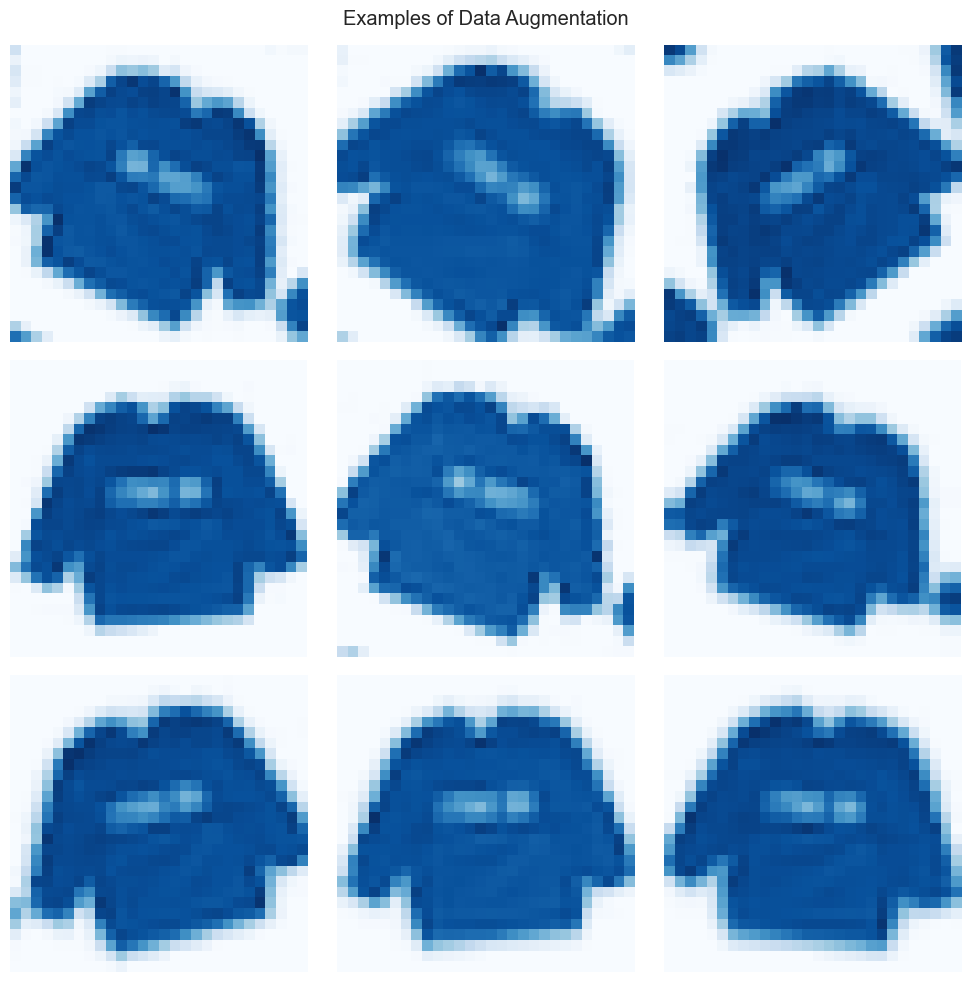

In [126]:
# visualizing data augmentation
image = X_train[0]

plt.figure(figsize=(10,10))

for i in range(9):

    augmented_image = data_augmentation(
        tf.expand_dims(image, 0),
        training=True
    )

    ax = plt.subplot(3, 3, i + 1)

    plt.imshow(
        augmented_image[0, :, :, 0], cmap='Blues')
    plt.axis("off")

plt.suptitle("Examples of Data Augmentation")
plt.tight_layout()
plt.show()

The figure above shows multiple augmented versions of the same Fashion-MNIST image.

In [127]:
# the base CNN architecture was kept unchanged and only an augmentation layer was added before the convolutional layers. 
augmented_model = Sequential([
    data_augmentation,

    Conv2D(filters=8, kernel_size=(5,5), padding='same', activation='relu', input_shape=(28,28,1)),
    MaxPooling2D((2,2)),

    Conv2D(filters=64, kernel_size=(3,3), activation='relu'),
    MaxPooling2D((2,2)),

    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.3),
    Dense(10, activation='softmax')
])

augmented_model.summary()

c:\Users\kavoshrayan\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_32"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_31 (Sequential)      │ (1, 28, 28, 1)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_60 (Conv2D)              │ (1, 28, 28, 8)         │           208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_57 (MaxPooling2D) │ (1, 14, 14, 8)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_61 (Conv2D)              │ (1, 12, 12, 64)        │         4,672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_58 (MaxPooling2D) │ (1, 6, 6, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_29 (Flatten)            │ (1, 2304)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_58 (Dense)                │ (1, 256)               │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_29 (Dropout)            │ (1, 256)               │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_59 (Dense)                │ (1, 10)                │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 597,530 (2.28 MB)

 Trainable params: 597,530 (2.28 MB)

 Non-trainable params: 0 (0.00 B)

In [128]:
augmented_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [129]:
aug_history = augmented_model.fit(
    X_train,
    y_train,
    epochs=15,
    batch_size=16,
    validation_split=0.2,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/15
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 53s 16ms/step - accuracy: 0.7365 - loss: 0.7039 - val_accuracy: 0.7713 - val_loss: 0.6072
Epoch 2/15
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 41s 14ms/step - accuracy: 0.8060 - loss: 0.5156 - val_accuracy: 0.8225 - val_loss: 0.5009
Epoch 3/15
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 33s 11ms/step - accuracy: 0.8305 - loss: 0.4533 - val_accuracy: 0.8540 - val_loss: 0.3978
Epoch 4/15
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 29s 10ms/step - accuracy: 0.8432 - loss: 0.4198 - val_accuracy: 0.8597 - val_loss: 0.3893
Epoch 5/15
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 33s 11ms/step - accuracy: 0.8517 - loss: 0.3980 - val_accuracy: 0.8619 - val_loss: 0.3802


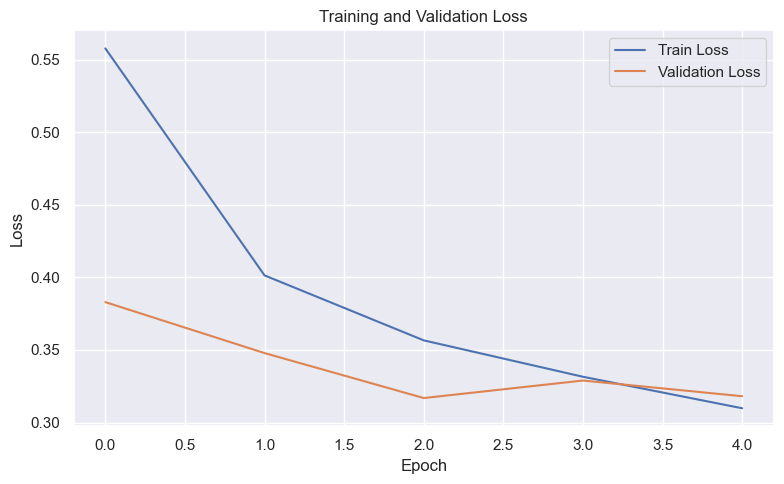

In [190]:
fig, ax = plt.subplots(figsize=(8,5))

ax.plot(aug_history.history['loss'], label='Train Loss')
ax.plot(aug_history.history['val_loss'], label='Validation Loss')
ax.set_title('Training and Validation Loss')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.grid(True)
ax.legend()

plt.tight_layout()
plt.show()

In [135]:
# evaluate model in test set
test_loss, test_accuracy = augmented_model.evaluate(
    X_test,
    y_test,
    verbose=0
)

y_pred = np.argmax(augmented_model.predict(X_test, verbose=0), axis=1)
y_true = np.argmax(y_test, axis=1)
f1 = f1_score(y_true, y_pred, average='macro')

print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_accuracy:.4f}")
print(f"F1 Score  : {f1:.4f}")

Test Loss     : 0.5839
Test Accuracy : 0.7750
F1 Score  : 0.7733


It led to a worse result.

Let's rebuild our augmentation layer.

In [192]:
# data augmentation applied using random rotations and zoom operations
data_augmentation = tf.keras.Sequential([
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.05)
])

augmented_model = Sequential([
    tf.keras.Input(shape=(28,28,1)),
    data_augmentation,

    Conv2D(filters=8, kernel_size=(5,5), padding='same', activation='relu', input_shape=(28,28,1)),
    MaxPooling2D((2,2)),

    Conv2D(filters=64, kernel_size=(3,3), activation='relu'),
    MaxPooling2D((2,2)),

    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.3),
    Dense(10, activation='softmax')
])

augmented_model.summary()

c:\Users\kavoshrayan\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_44"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_43 (Sequential)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_72 (Conv2D)              │ (None, 28, 28, 8)      │           208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_69 (MaxPooling2D) │ (None, 14, 14, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_73 (Conv2D)              │ (None, 12, 12, 64)     │         4,672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_70 (MaxPooling2D) │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_35 (Flatten)            │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_76 (Dense)                │ (None, 256)            │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_41 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_77 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 597,530 (2.28 MB)

 Trainable params: 597,530 (2.28 MB)

 Non-trainable params: 0 (0.00 B)

In [193]:
augmented_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [194]:
aug_history = augmented_model.fit(
    X_train,
    y_train,
    epochs=15,
    batch_size=16,
    validation_split=0.2,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/15
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 77s 24ms/step - accuracy: 0.7936 - loss: 0.5619 - val_accuracy: 0.8633 - val_loss: 0.3853
Epoch 2/15
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 88s 29ms/step - accuracy: 0.8527 - loss: 0.3958 - val_accuracy: 0.8802 - val_loss: 0.3367
Epoch 3/15
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 83s 28ms/step - accuracy: 0.8698 - loss: 0.3522 - val_accuracy: 0.8892 - val_loss: 0.3149
Epoch 4/15
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 87s 29ms/step - accuracy: 0.8789 - loss: 0.3241 - val_accuracy: 0.8888 - val_loss: 0.3171
Epoch 5/15
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 95s 32ms/step - accuracy: 0.8851 - loss: 0.3099 - val_accuracy: 0.8944 - val_loss: 0.2981


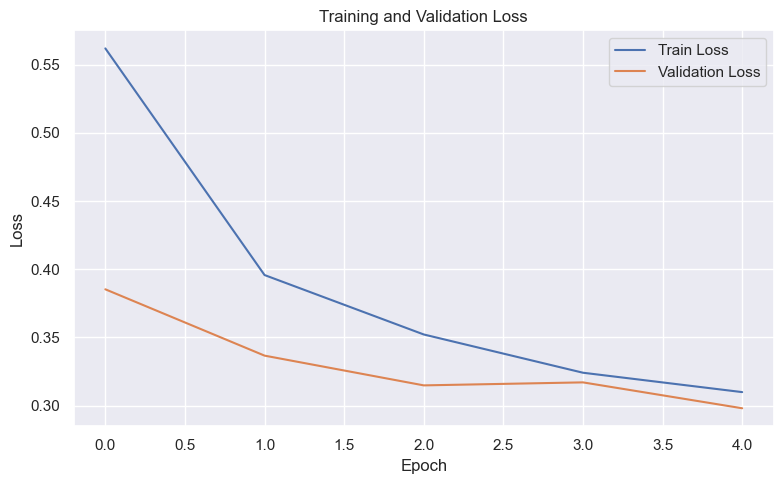

In [195]:
fig, ax = plt.subplots(figsize=(8,5))

ax.plot(aug_history.history['loss'], label='Train Loss')
ax.plot(aug_history.history['val_loss'], label='Validation Loss')
ax.set_title('Training and Validation Loss')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.grid(True)
ax.legend()

plt.tight_layout()
plt.show()

In [196]:
test_loss, test_accuracy = augmented_model.evaluate(
    X_test,
    y_test,
    verbose=0
)

y_pred = np.argmax(augmented_model.predict(X_test, verbose=0), axis=1)
y_true = np.argmax(y_test, axis=1)
f1 = f1_score(y_true, y_pred, average='macro')

print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_accuracy:.4f}")
print(f"F1 Score  : {f1:.4f}")

Test Loss     : 0.3627
Test Accuracy : 0.8655
F1 Score  : 0.8623


It got better..!

Let's examine misclassified test samples to better understand model behavior.

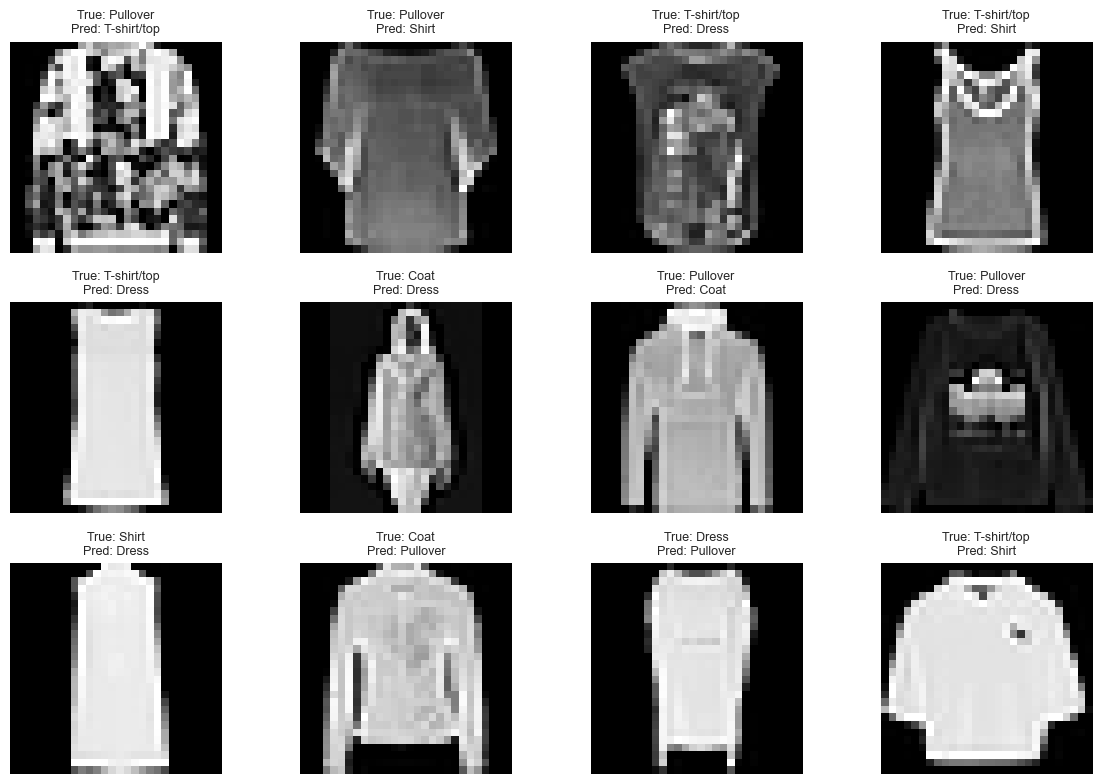

In [148]:
misclassified = np.where(y_pred != y_true)[0]

plt.figure(figsize=(12,8))

for i, idx in enumerate(misclassified[:12]):

    plt.subplot(3, 4, i+1)

    plt.imshow(X_test[idx].squeeze(), cmap='gray')

    plt.title(
        f"True: {labels[y_true[idx]]}\n"
        f"Pred: {labels[y_pred[idx]]}",
        fontsize=9
    )

    plt.axis('off')

plt.tight_layout()
plt.show()

Several errors occurred between visually similar clothing categories such as Shirts, T-shirts, Pullovers, and Coats. These classes share similar shapes and textures, making them difficult to distinguish in low-resolution grayscale images.

This suggests that the CNN successfully learned meaningful visual features but remains challenged by classes with overlapping visual characteristics.


##### Effect of Data Augmentation :

Contrary to expectations, the augmented model achieved lower performance than the base CNN.

The base model obtained 92.1% test accuracy, whereas the augmented model achieved 86.5% accuracy. This behavior can be attributed to the characteristics of Fashion-MNIST. Since the dataset already contains a large number of training examples and the images are only 28×28 pixels, geometric transformations may distort important visual details rather than providing useful variability.

Although augmentation is often used to reduce overfitting and improve generalization, its effectiveness depends on the dataset and the chosen transformations. In this case, augmentation increased training difficulty and resulted in lower overall performance.

## Transfer Learning with MobileNetV2

MobileNetV2 was selected as the pretrained model because it provides a strong balance between performance and computational efficiency.
 
### Feature Extraction

A pretrained MobileNetV2 model with ImageNet weights was used as a feature extractor. All layers of the pretrained network were frozen (**trainable=False**), and only the newly added classification head was trained on Fashion-MNIST.


In [180]:
from tensorflow.keras.applications import MobileNetV2

mn_base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)  # i could'nt use input_shape = (96, 96, 3) bacause of limited internet access...(403 Error!)
)

mn_base_model.trainable = False

MobileNetV2 requires RGB images of size 224×224, whereas Fashion-MNIST consists of 28×28 grayscale images. Therefore, a resizing layer and a grayscale-to-RGB conversion step were added before the pretrained network. (converted to three-channel RGB format)

These operations were placed inside the model to avoid creating a separate resized dataset, reduce memory usage, and keep the preprocessing pipeline fully integrated with the network.

A custom classification head was added on top of the pretrained MobileNetV2 backbone. The head consists of a Global Average Pooling layer followed by a fully connected layer with 256 neurons, dropout regularization.

In [181]:
inputs = tf.keras.Input(shape=(28,28,1))

# resize
x = layers.Resizing(224,224)(inputs)

# grayscale -> RGB
x = layers.Concatenate()([x,x,x])

# pretrained backbone
x = mn_base_model(x, training=False)

# classification head
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)

# fully connected layers
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.3)(x)

# softmax output layer
outputs = layers.Dense(10, activation='softmax')(x)

transfer_model = Model(inputs, outputs)
transfer_model.summary()

Model: "functional_242"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_55      │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resizing_4          │ (None, 224, 224,  │          0 │ input_layer_55[0… │
│ (Resizing)          │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_4       │ (None, 224, 224,  │          0 │ resizing_4[0][0], │
│ (Concatenate)       │ 3)                │            │ resizing_4[0][0], │
│                     │                   │            │ resizing_4[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mobilenetv2_1.00_2… │ (None, 7, 7,      │  2,257,984 │ concatenate_4[0]… │
│ (Functional)        │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 1280)      │          0 │ mobilenetv2_1.00… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_39          │ (None, 1280)      │          0 │ global_average_p… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_74 (Dense)    │ (None, 256)       │    327,936 │ dropout_39[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_40          │ (None, 256)       │          0 │ dense_74[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_75 (Dense)    │ (None, 10)        │      2,570 │ dropout_40[0][0]  │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,588,490 (9.87 MB)

 Trainable params: 330,506 (1.26 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [182]:
transfer_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [183]:
history_tl = transfer_model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1218s 802ms/step - accuracy: 0.8266 - loss: 0.4790 - val_accuracy: 0.8767 - val_loss: 0.3411
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1061s 708ms/step - accuracy: 0.8608 - loss: 0.3738 - val_accuracy: 0.8842 - val_loss: 0.3146
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1062s 708ms/step - accuracy: 0.8710 - loss: 0.3460 - val_accuracy: 0.8843 - val_loss: 0.3114
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1073s 715ms/step - accuracy: 0.8761 - loss: 0.3293 - val_accuracy: 0.8903 - val_loss: 0.2986
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1147s 765ms/step - accuracy: 0.8803 - loss: 0.3172 - val_accuracy: 0.8956 - val_loss: 0.2857


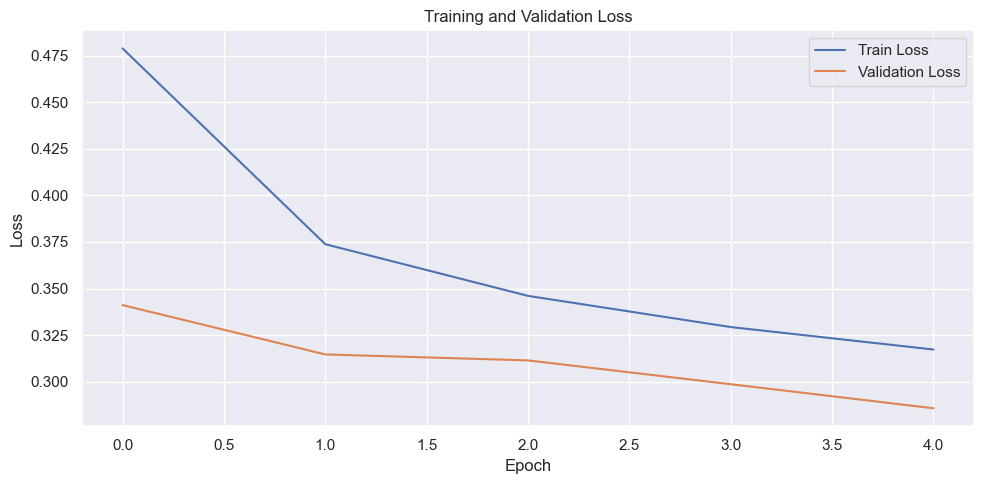

In [189]:
plt.figure(figsize=(10,5))

plt.plot(history_tl.history['loss'],label='Train Loss')
plt.plot(history_tl.history['val_loss'],label='Validation Loss')

plt.title("Training and Validation Loss")
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [188]:
test_loss, test_acc = transfer_model.evaluate(
    X_test,
    y_test,
    verbose=0
)

y_pred = np.argmax(transfer_model.predict(X_test), axis=1)
y_true = np.argmax(y_test, axis=1)

f1 = f1_score(y_true, y_pred, average='macro')

print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_accuracy:.4f}")
print(f"F1 Score  : {f1:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 243s 766ms/step
Test Loss     : 0.3342
Test Accuracy : 0.8646
F1 Score  : 0.8737


The transfer learning model achieved an accuracy of 86.46% and an F1-score of 87.37%, which was lower than the custom CNN developed in Part A (base model : 92.09% accuracy).

A likely explanation is the significant domain difference between ImageNet images and Fashion-MNIST. Furthermore, only feature extraction was performed, preventing the pretrained backbone from adapting its representations to the target dataset.

Despite the lower final accuracy, transfer learning showed stable training behavior and no signs of overfitting.

## Discussion Question

### Why are CNNs fundamentally more parameter-efficient than MLPs when dealing with high-dimensional inputs such as images?


CNNs are more parameter-efficient because they use local connectivity and weight sharing.

In a CNN, each filter (kernel) is applied across the entire image, meaning the same set of weights is reused at every spatial location. For example, a 3×3 filter contains only 9 weights (plus biases), regardless of the image size. This allows CNNs to learn useful visual patterns such as edges, textures, and shapes with relatively few parameters.

In contrast, an MLP treats an image as a flat vector. Every neuron in a fully connected layer must connect to every input pixel, resulting in a very large number of parameters. For a 28×28 image (784 pixels), a hidden layer with 512 neurons already requires:  784×512=401,408
weights, not including biases. As image resolution increases, the number of parameters grows rapidly.



### Under what conditions could an MLP theoretically match CNN performance, and why is this unrealistic in practical scenarios?

According to the universal approximation theorem, a sufficiently large MLP can approximate the same functions that a CNN can learn . If given enough hidden layers, neurons, training data and computational resources, an MLP could theoretically achieve similar performance.

This is unrealistic in practical scenarios because to match a CNN, an MLP would need to learn from raw pixels without any built-in knowledge of image structure. This creates several problems like :
- Massive number of parameters

For example, a 224×224 RGB image contains 224×224×3=150,528 input values. Connecting this to a hidden layer of only 1,000 neurons would require more than 150,528×1,000≈150 million weights in a single layer.

- More training data required bacause CNNs already assume that nearby pixels are related and that patterns can appear anywhere in the image.
MLPs must learn these properties from data alone.

- Greater risk of overfitting since the large parameter count makes memorization easier.